# Functions and algorithms

GDP is an aggregate statistic measuring the amount of money flowing through an economy. Using quarterly data of GDP growth rates from 2010 to 2023, the techniques of cubic splines, polynomial fits, and linear regression will be tested and analyzed to illustrate how different modeling/interpolation methods respond to real-world data. Cubic splines use exact interpolation to create smooth graphs connecting each point. Polynomial fits use a single polynomial function of some degree (in this case degree 4) to model the overall behavior of a function. Linear regressions consist of a single line that attempts to determine the trend of the set of data. After defining the algorithms needed to perform these techniques, each will be tried and analyzed accordingly.

In [208]:
import numpy as np
import matplotlib.pyplot as plt

In [209]:
def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]           # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])         # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])         # Right-hand side vector

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

In [210]:
def construct_M(x, y):
    #solves tridiagonal matrix
    N = len(x)
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    M_inner = thomas_algorithm(A, B, C, D)
    M_data = np.zeros(N)
    M_data[1:-1] = M_inner
    return M_data

In [211]:
def linear_regression(x, y):
    n = len(x)
    
    x_mean = sum(x) / n
    y_mean = sum(y) / n
    numerator = 0
    denominator = 0
    
    #sums
    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean)
        denominator += (x[i] - x_mean) ** 2

    m = numerator / denominator
    b = y_mean - m * x_mean

    return m, b

In [212]:
def poly_vander_fit(x, y, degree):
    #create vandermonde matrix
    V = np.zeros((len(x), degree+1))
    for i in range (0, degree + 1):
        V[:, i] = x ** i
    check_condition_number(V)

    #solve normal equations
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients

In [213]:
def RMSE(real_data, pred_data):
    total_error = 0
    for i in range(0, len(real_data)):
        total_error += (real_data[i] - pred_data[i])**2
    MSE = (total_error) / float(len(real_data))
    RMSE = np.sqrt(MSE)
    return RMSE

In [214]:
def R_squared(real_data, pred_data):
    denom = np.sum((real_data - np.mean(real_data))**2)
    numerator = np.sum((real_data - pred_data)**2)
    r_squared = 1 - (numerator / denom)
    return r_squared

In [215]:
def check_condition_number(V):
    L = np.dot(V, V.T)
    cond = np.linalg.cond(L)
    print('Condition number of V: ', cond)
    if cond > 1e12:
        print('condition number too high!')
    else:
        print('reasonable condition number')

# Part A: Cubic Spline Interpolation

In [216]:
#initialize data
x_years = np.array([10, 11, 12, 13, 14, 14, 15, 16, 16, 16 ,17, 18, 19, 20, 20, 20 ,21, 22, 23, 23])
x_quarters = np.array([1, 1, 1, 1, 1, 3, 2, 1, 3, 4, 1, 1, 1, 1, 2, 3, 1, 1, 2, 4])
q = np.zeros(len(x_years))
for i in range(0, len(x)):
    q[i] = (x_years[i] - 10)*4 + x_quarters[i]
print(q)
gdp = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

[ 1.  5.  9. 13. 17. 19. 22. 25. 27. 28. 29. 33. 37. 41. 42. 43. 45. 49.
 54. 56.]


Text(0.5, 1.0, 'Cubic Spline Interpolation of Quarterly GDP changes')

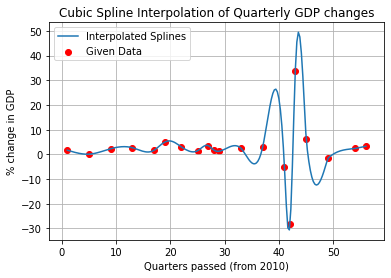

In [217]:
#cubic splines
M = construct_M(q, gdp)
q_lin = np.linspace(1, 56, 200)
spline_pred = evaluate_spline(q, gdp, M, q_lin)

plt.plot(q_lin, spline_pred, label = 'Interpolated Splines')
plt.scatter(q, gdp, c = 'red', label = 'Given Data')
plt.grid()
plt.xlabel('Quarters passed (from 2010)')
plt.ylabel('% change in GDP')
plt.legend()
plt.title('Cubic Spline Interpolation of Quarterly GDP changes')

The cubic spline interpolation works by solving a tridiagonal matrix of 
main diagonal B representing the current second derivative, sub and super diagonals A and C that represent the edges of the spline, and right hand side vector D that uses derivatives to ultimately linearize the cubic problem and make it solvable. Then, the matrix is quickly evaluated using the Thomas Algorithm, and then integrated back up to create the actual cubic spline.

There are 20 given data points, and thus 19 splines connecting between them. There are continuity conditions for the splines: at intersection points, connecting splines must have equal value, equal first derivative, and equal second derivative. This is enforced by solving for the second derivatives first with the tridiagonal matrix and integrating upwards from there. A natural spline means that at the endpoints, the second derivatives are equal to zero. 

Since there are 19 splines and 4 coefficients needed for each, there 76 total unknowns, thus 76 equations are needed to define the system. Equal first derivatives and equal second derivates at the knots of the splines each provide 18 equations, totaling 36. Since each spline has to hit an exact points at each end, all 19 splines provide 2 more equations, totaling 74 equations. The final two come from the second derivatives on both ends needing to be 0. Thus, 76 equations define the system.

# A2

Text(0.5, 1.0, 'Cubic Spline Interpolation Marking Each Quarter')

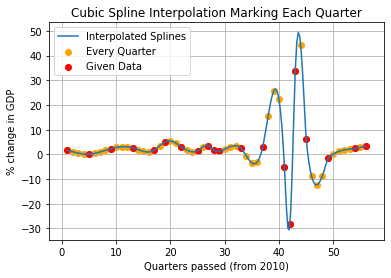

In [218]:
#splines interpolating all quarters
q_interp = np.linspace(1, 56, 56)

plt.plot(q_lin, spline_pred, label = 'Interpolated Splines')
plt.scatter(q_interp, evaluate_spline(q, gdp, M, q_interp), c = 'orange', label = 'Every Quarter')
plt.scatter(q, gdp, c = 'red', label = 'Given Data')
plt.grid()
plt.xlabel('Quarters passed (from 2010)')
plt.ylabel('% change in GDP')
plt.legend()
plt.title('Cubic Spline Interpolation Marking Each Quarter')

The interpolant is quite smooth and fairly reasonable. Especially during the small perturbations, the splines are able to give curves that do not vary wildly while still hitting every point. However, around the outliers, the spline has a tendency to overshoot. It results in a very nice looking graph, but it seems like this behavior is a guess that appears appealing rather than a prediction made given the actual data. The local maximum before Quarter 44 is the most apparent moment where this occurs as the cubic function tries to smooth out the transition before going sharply down between the real data from Quarter 43 and 45.

# A3

The Runge Phenomenon is an effect that occurs when using high degree polynomials to approximate a set of data where the error towards the edges of the data becomes increasingly large. The cubic spline model effectively eliminates this effect by creating a separate equation governing each gap between points, maintaining exact points and keeping the degree low. However, the trade-off for using exact interpolation is that the method becomes less numerically stable. This means that small changes in the data can create vastly different outcomes in the model, implying that noise in the data can completely change predictions. Exact interpolations assume that there is no noise in the data. Thus, non-exact techniques like smoothing splines or weighted least squares would be preferable for situations like the 2020 Q2 outlier of 28.1 to stop the trend of the data from overshotting due to this outlier caused by COVID.

# Part B: Polynomial & Least Squares

Condition number of V:  3.097382832735399e+22
condition number too high!


Text(0.5, 1.0, 'Degree 4 Polynomial Fit Against Cubic Spline Interpolation')

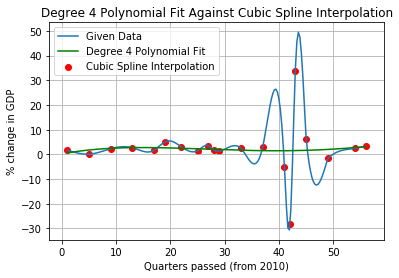

In [219]:
#degree 4 polynomial
coefficients = poly_vander_fit(q, gdp, 4)
polynomial = np.poly1d(coefficients[::-1])
poly_pred = polynomial(q_lin)

plt.plot(q_lin, spline_pred, label = 'Given Data')
plt.scatter(q, gdp, c = 'red', label = 'Cubic Spline Interpolation')
plt.plot(q_lin, poly_pred, 'g', label = 'Degree 4 Polynomial Fit')
plt.grid()
plt.xlabel('Quarters passed (from 2010)')
plt.ylabel('% change in GDP')
plt.legend()
plt.title('Degree 4 Polynomial Fit Against Cubic Spline Interpolation')

Root Mean Squared Error:  10.031440678677116
R^2:  0.00354101511853977


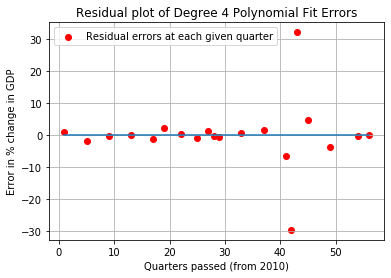

In [220]:
#calculate residuals
poly_pred_at_q = polynomial(q)
resid_polyfit = np.zeros(len(q))

for i in range(0, len(q)):
    resid_polyfit[i] = gdp[i]-poly_pred_at_q[i]
    
plt.scatter(q, resid_polyfit, c = 'r', label = 'Residual errors at each given quarter')
plt.plot(q_lin, q_lin * 0)
plt.grid()
plt.xlabel('Quarters passed (from 2010)')
plt.ylabel('Error in % change in GDP')
plt.legend()
plt.title('Residual plot of Degree 4 Polynomial Fit Errors')

#RMSE
print('Root Mean Squared Error: ', RMSE(gdp, poly_pred_at_q))

#R^2
print('R^2: ', R_squared(gdp, poly_pred_at_q))

The degree 4 polynomial is better at capturing the overall trend of a slight general increase then general decrease in % change every quarter, but the cubic spline produced better specific data points. There exists a trade-off between approximation and interpolation such that by choosing to more precisely interpolate and recreate the exact data set, the model loses some ability to effectively approximate trends in favor of trying to be precise. However, in some cases this is completely unnecessary because the noise/randomness of the data means that the exact numbers do not matter and the trend is the more important result. Unfortunately, the condition number of the vandermonde matrix is quite high, so this data is very sensitive and could experience calculation errors. Cubic splines give great interpolations, but polynomials give good approximations and trend information.

# B2

In [221]:
#removing COVID data
x_years_noCOVID = np.array([10, 11, 12, 13, 14, 14, 15, 16, 16, 16 ,17, 18, 19, 22, 23, 23])
x_quarters_noCOVID = np.array([1, 1, 1, 1, 1, 3, 2, 1, 3, 4, 1, 1, 1, 1, 2, 4])
gdp_NC = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

q_NC = np.zeros(len(x_years_noCOVID))
for i in range(0, len(x_years_noCOVID)):
    q_NC[i] = (x_years_noCOVID[i] - 10)*4 + x_quarters_noCOVID[i]

Slope:  -0.0019069881889763815


Text(0.5, 1.0, 'Linear Regression of Quarterly GDP Change')

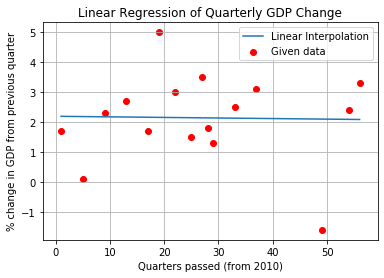

In [222]:
#linear least squares
m, b = linear_regression(q_NC, gdp_NC)
print('Slope: ', m)

plt.plot(q_lin, q_lin * m + b, label = 'Linear Interpolation')
plt.scatter(q_NC, gdp_NC, c = 'red', label = 'Given data')
plt.grid()
plt.xlabel('Quarters passed (from 2010)')
plt.ylabel('% change in GDP from previous quarter')
plt.legend()
plt.title('Linear Regression of Quarterly GDP Change')

Root Mean Squared Error:  1.4431864883291987
R-Squared:  0.00044329440682566723


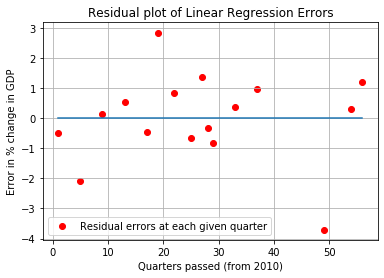

In [223]:
#calculate residuals
resid_regression = np.zeros(len(q_NC))
for i in range(0, len(q_NC)):
    resid_regression[i] = gdp_NC[i]-(q_NC[i]*m + b)
    
plt.scatter(q_NC, resid_regression, c = 'r', label = 'Residual errors at each given quarter')
plt.plot(q_lin, q_lin * 0)
plt.grid()
plt.xlabel('Quarters passed (from 2010)')
plt.ylabel('Error in % change in GDP')
plt.legend()
plt.title('Residual plot of Linear Regression Errors')

#RMSE
print('Root Mean Squared Error: ', RMSE(gdp_NC, q_NC*m + b))

#R^2
print('R-Squared: ', R_squared(gdp_NC, q_NC*m + b))

The slope of the least squares linear model is m = -0.0019069881889763815, which would only make sense under the assumption that the growth of the economy is changing at a constant rate. This slope actually means that given this data, the economy is growing at an ever-so-slightly slightly decreasing rate.

This is quite an extreme assumption to make, as economic factors such as political decisions (tariffs, embargos, taxes, etc) can make drastic changes to the GDP rapidly (on top of shocking world events like COVID-19). The boom bust cycle of economics also might pose an issue when trying to extrapolate this model out; the economy only grows so much until it comes down again. The extremely low R^2 (0.000433) also shows that the % change in GDP can barely be attributed to time.

This low relation looks even worse when considering that the COVID outliers had already been removed from this data set. The linear approach is saying very little and the data shows it.

The root mean squared error is 1.4431864883291987, which appears low, but is actually quite high considering that the highest value in the data set is 5 (in terms of percent change GDP).

# Part C: Method Justification

The policymaker should use cubic splines rather than degree 4 polynomial fit to interpolate for the quarter between the two known data points. Although cubic splines are sensitive to outliers, they are smooth and extremely accurate at hitting specific points. Since this is a relatively time-local analysis, it makes sense to choose the technique that creates an individual model for every quarter. 

Polynomial fits would do a better job at not reacting to outliers in data early nor overshooting after hitting an outlier, but the data is definitely too noisy and random for the polynomial fit to be accurate enough on any scale (plus the condition number issue that makes its precision questionable through the solver). This is evidenced by the low R^2 value of 0.00354 which shows that variation in % change GDP cannot be highly attributed to time. Thus, it makes more sense to assume that the graph should be interpolated exactly rather than trying to model a trend that does not really exist. Also, cubic splines have a significantly lower error, with a Root Mean Squared Error of 0 over the entire model (or any given quarter). However, polynomial fit has a RMSE of 10.031 over the model.

The linear regression and polynomial fit will do a poor job at actually moving between the policymaker's points because they are trying to model the overall trend of the % change of GDP rather than the change of % change between quarters like the cubic splines. The condition number of the polynomial fit is also naturally very high, which makes it more sensitive to input changes and may result in precision loss.

# Big O

Big O notation is a technique for measuring the time-complexity of an algorithm by describing how it scales computational intensity given the size of the input. It may affect which technique one chooses to use if a massive decrease in intensity does not cost much accuracy.

Cubic splines are O(n) time complexity. This is because its fairly optimized algorithm never needs to nest for loops, so it at most has to scale with the length of the vector input in a single for loop. This is not the best possible time complexity, but it is very good.

The polynomial fit is an O(n^3) time complexity. This is because it requires using np.linalg.solve on the vandermonde matrix, which acts as the dominant term and operates at O(n^3) because the solving of matrices is done by LU decomposition (splitting matrix into upper and lower triangular matrices). Eliminating down the column takes n^2 operations, then there are n columns to do this for, resulting in O(n^3). This is significantly less efficient than cubic splines, as doubling the size of the input increases the time to calculate by a factor of 8 (as opposed to only doubling!).

Linear regression is an O(n) time complexity. This is because only linearly scaled operations occur (no nested loops) such as taking the mean and single for loops parsing the data.

Cubic splines and linear regression have significantly better time complexities than the polynomial fit. Since cubic splines was already the recommended method, nothing has changed as this stance has been further solidified.
This calls into question whether the linear regression or polynomial fit better represent the trend, but the horrible R^2 of the linear regression and relatively low computational intensity of only 56 quarters. Polynomial fit has a higher RMSE, but the comparison is not fair on this statistic because polynomial fit data included the outliers.

Cubic splines are still the recommended strategy for the policymaker's purpose.

Below is a graph demonstrating the difference in these time complexities as the size of the input increases.

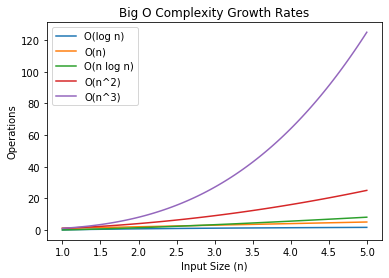

In [224]:
n = np.linspace(1, 5, 100)
plt.plot(n, np.log(n), label='O(log n)')
plt.plot(n, n, label='O(n)')
plt.plot(n, n * np.log(n), label='O(n log n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, n**3, label='O(n^3)')

plt.title('Big O Complexity Growth Rates')
plt.xlabel('Input Size (n)')
plt.ylabel('Operations')
plt.legend()
plt.show()

# Conclusion

In conclusion, cubic splines would be best used for maintaining exact data and smooth interpolations while polynomial fit would be best used for determining the overall trend during these 13 years. None of these methods could likely be used to accurately extrapolate outside of data set, but the cubic splines and polynomial fit provide useful analysis of these different priorites.

I have learned that linear regressions can be hard to use for interior approximations or even trends by rapidly oscillating data in a situation where data can be affected by many variables, and that polynomial fits can actually be hard to scale due to their high time complexity O(n^3). Cubic splines become extra impressive due to their high precision with low time complexity O(n).

Different interpolation techniques become useful when their circumstance arises. Linear regressions are great for quickly finding the trend between an dependent and indendent variable when they are actually correlated, but not when they are practically independent of each other. It also does a decent job at sifting through noisy data, but not so much random perturbations. Cubic splines build clean, smooth, and accurate curves between precise data, but can become quite falty when the data is noisy and risks serious overshoot. Polynomial fits are effective ways to find general trends, but one needs to be cautious of the Runge effect to not use too high of a degree that it creates extra error.

I learned that even when methods look like they are doing a good job capturing trends, they might still be on shaky foundations due to computational precision that could become a bigger problem at scale. Condition numbers are a way to diagnose this issue before deploying the method to fail.

All have their strengths and weaknesses, but this policymaker should likely use the cubic splines to interpolate the micro-trends between two data points.